# Importing

In [1]:
import os
# import kagglehub
import random
import numpy as np
import hashlib
import tempfile
from PIL import Image
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv2D, Input, GlobalAveragePooling2D,
    BatchNormalization, Activation, Concatenate, Add, MaxPooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, f1_score
)
from collections import Counter
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-05-02 14:04:43.162443: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777730683.347441      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777730683.401871      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777730683.839143      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777730683.839185      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777730683.839187      57 computation_placer.cc:177] computation placer alr

# DataSet

installing dataset

In [2]:
# data_dir = kagglehub.dataset_download('ismailnasri20/driver-drowsiness-dataset-ddd')

# print('Dataset downloaded to:', data_dir)

In [3]:
!pip install datasets

In [4]:
from datasets import load_dataset
ds = load_dataset("n7i5x9/driver-drowsiness-dataset")
print(ds["train"][0])

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/337M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/86.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/86.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18492 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2311 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2313 [00:00<?, ? examples/s]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x640 at 0x7B04C8C843B0>, 'label': 0}


In [5]:
print(ds)

# Access the first training sample
first_train_sample = ds['train'][0]

# Print the keys available in the sample
print(f"\nKeys in the first training sample: {first_train_sample.keys()}")

# Display the image and its label
print(f"Label of the first training sample: {first_train_sample['label']}")
# display(first_train_sample['image'])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 18492
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2311
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2313
    })
})

Keys in the first training sample: dict_keys(['image', 'label'])
Label of the first training sample: 0


Split Data

In [6]:
import os
import shutil
import hashlib
import gc
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# =====================================================
# CONFIG
# =====================================================

# Kaggle dataset folder
kaggle_dir = "/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)"

# Hugging Face DatasetDict
hf_ds = ds   # your printed DatasetDict

# Output merged folder
output_dir = "/kaggle/working/merged_dataset"

# Resize for consistency + lower storage
img_size = (300, 300)

# HF labels (edit if reversed)
label_map = {
    0: "Drowsy",
    1: "Non_Drowsy"
}

# Kaggle folder names mapping
folder_map = {
    "Drowsy": "Drowsy",
    "Non Drowsy": "Non_Drowsy",
    "Non_Drowsy": "Non_Drowsy",
    "Not_Drowsy": "Non_Drowsy"
}

# =====================================================
# START
# =====================================================

print("Starting merge")
print("Kaggle source :", kaggle_dir)
print("HF rows       :", sum(len(hf_ds[x]) for x in hf_ds.keys()))
print("Output folder :", output_dir)

os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, "Drowsy"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "Non_Drowsy"), exist_ok=True)

# =====================================================
# HASH SYSTEM
# =====================================================

seen_hashes = set()

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def image_hash(img):
    return hashlib.md5(img.tobytes()).hexdigest()

# =====================================================
# 1. MERGE KAGGLE DATASET
# =====================================================

print("\nMerging Kaggle dataset")

kaggle_count = 0
kaggle_skip = 0

for folder in os.listdir(kaggle_dir):
    folder_path = os.path.join(kaggle_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    if folder not in folder_map:
        continue

    target_class = folder_map[folder]
    target_dir = os.path.join(output_dir, target_class)

    for file in tqdm(os.listdir(folder_path), desc=folder):
        src = os.path.join(folder_path, file)

        try:
            h = file_hash(src)

            if h in seen_hashes:
                kaggle_skip += 1
                continue

            seen_hashes.add(h)

            ext = Path(file).suffix.lower()
            new_name = f"kaggle_{kaggle_count}{ext}"

            shutil.copy2(src, os.path.join(target_dir, new_name))
            kaggle_count += 1

        except:
            kaggle_skip += 1

# =====================================================
# 2. MERGE HF DATASETDICT (RAM SAFE)
# =====================================================

print("\nMerging Hugging Face dataset")

hf_count = 0
hf_skip = 0

for split in hf_ds.keys():

    print("Processing split:", split)

    for i, item in enumerate(tqdm(hf_ds[split])):

        try:
            img = item["image"].convert("RGB")
            img = img.resize(img_size)

            label = label_map[item["label"]]
            save_dir = os.path.join(output_dir, label)

            h = image_hash(img)

            if h in seen_hashes:
                hf_skip += 1
                continue

            seen_hashes.add(h)

            save_path = os.path.join(save_dir, f"hf_{split}_{i}.jpg")
            img.save(save_path, quality=95)

            hf_count += 1

            if i % 500 == 0:
                gc.collect()

        except:
            hf_skip += 1

# =====================================================
# REPORT
# =====================================================

print("\nFinished Merge")
print("Kaggle copied :", kaggle_count)
print("HF copied     :", hf_count)
print("Skipped total :", kaggle_skip + hf_skip)

for cls in ["Drowsy", "Non_Drowsy"]:
    path = os.path.join(output_dir, cls)
    print(cls, ":", len(os.listdir(path)))

print("\nReady at:")
print(output_dir)

Starting merge
Kaggle source : /kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)
HF rows       : 23116
Output folder : /kaggle/working/merged_dataset

Merging Kaggle dataset


Drowsy: 100%|██████████| 22348/22348 [03:55<00:00, 94.88it/s] 



Merging Hugging Face dataset
Processing split: train


100%|██████████| 18492/18492 [02:39<00:00, 116.28it/s]


Processing split: validation


100%|██████████| 2311/2311 [00:19<00:00, 118.98it/s]


Processing split: test


100%|██████████| 2313/2313 [00:19<00:00, 117.84it/s]


Finished Merge
Kaggle copied : 41793
HF copied     : 19237
Skipped total : 3879
Drowsy : 33460
Non_Drowsy : 27570

Ready at:
/kaggle/working/merged_dataset


In [7]:
!pip install split-folders

In [8]:
import splitfolders

input_dir = '/kaggle/working/merged_dataset'
output_dir = "/dataset/working/splited_dataset"

splitfolders.ratio(
    input=input_dir,
    output=output_dir,
    seed=42,
    ratio=(.8, .15, .05)
)

Copying files: 61030 files [00:12, 4768.59 files/s]


In [9]:
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

In [10]:
def get_all_files(base_dir):
    all_files = set()

    for class_name in os.listdir(base_dir):  # Drowsy / Not_Drowsy
        class_path = os.path.join(base_dir, class_name)

        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                full_path = os.path.join(class_name, file)
                all_files.add(full_path)

    return all_files


train_files = get_all_files(train_dir)
val_files = get_all_files(val_dir)
test_files = get_all_files(test_dir)


print("Train files Len:", len(train_files))
print("Val files Len:", len(val_files))
print("Test files Len:", len(test_files))
print("Train-Val Overlap:", len(train_files & val_files))
print("Train-Test Overlap:", len(train_files & test_files))
print("Val-Test Overlap:", len(val_files & test_files))

Train files Len: 48824
Val files Len: 9154
Test files Len: 3052
Train-Val Overlap: 0
Train-Test Overlap: 0
Val-Test Overlap: 0


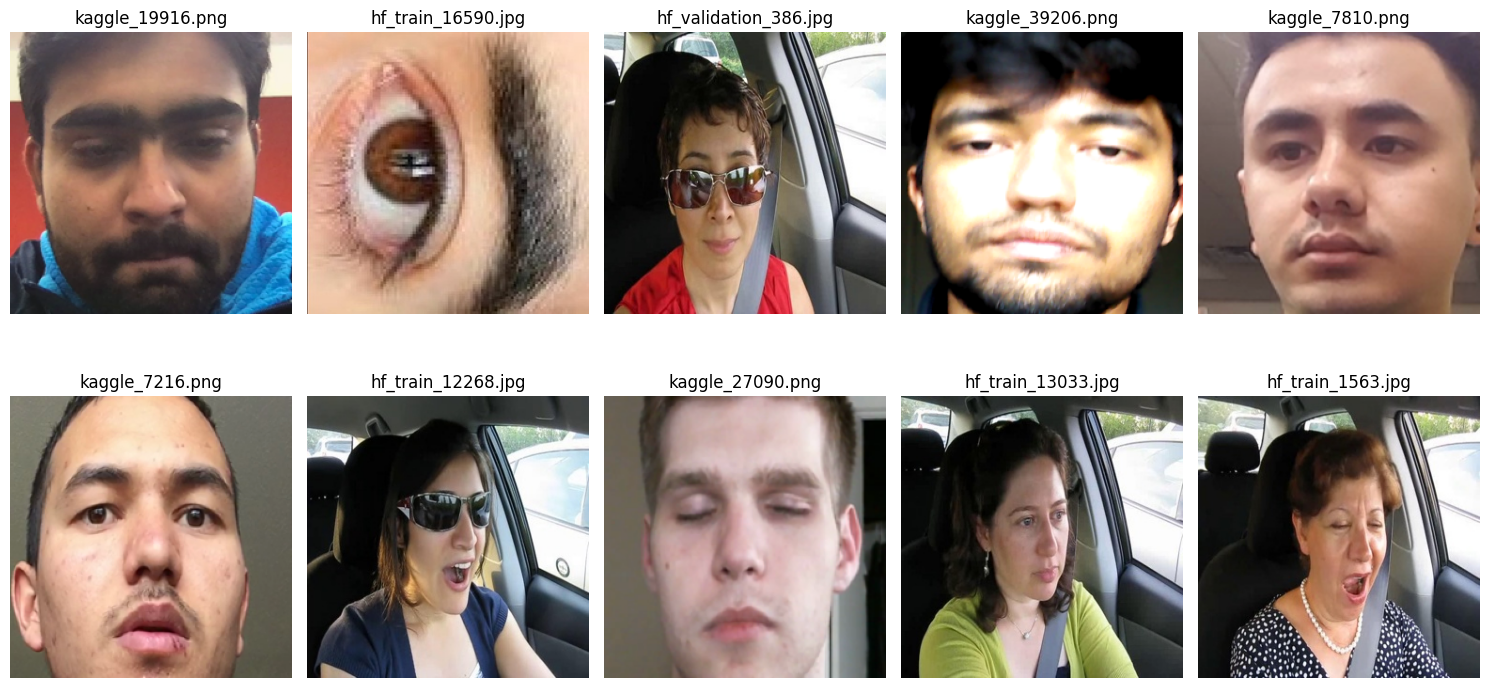

In [11]:
import matplotlib.image as mpimg

def show_images(file_set, base_dir, n=10):
    file_list = list(file_set)
    samples = random.sample(file_list, min(n, len(file_list)))

    plt.figure(figsize=(15, 8))

    for i, rel_path in enumerate(samples):
        full_path = os.path.join(base_dir, rel_path)

        img = mpimg.imread(full_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(rel_path.split('/')[-1])

    plt.tight_layout()
    plt.show()


show_images(train_files, train_dir, 10)

# Data Augmentation

Variables

In [12]:
img_size = (300,300)
batch_size = 32

In [13]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.25,

    horizontal_flip=True,

    # brightness_range=[0.7, 1.3],

    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(
    # preprocessing_function=preprocess_input
)

In [14]:
train_batches = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=True, seed=SEED
)
val_batches = test_val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=True, seed=SEED
)
test_batches = test_val_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=False, seed=SEED
)

Found 48824 images belonging to 2 classes.
Found 9154 images belonging to 2 classes.
Found 3052 images belonging to 2 classes.


Found 48824 images belonging to 2 classes.


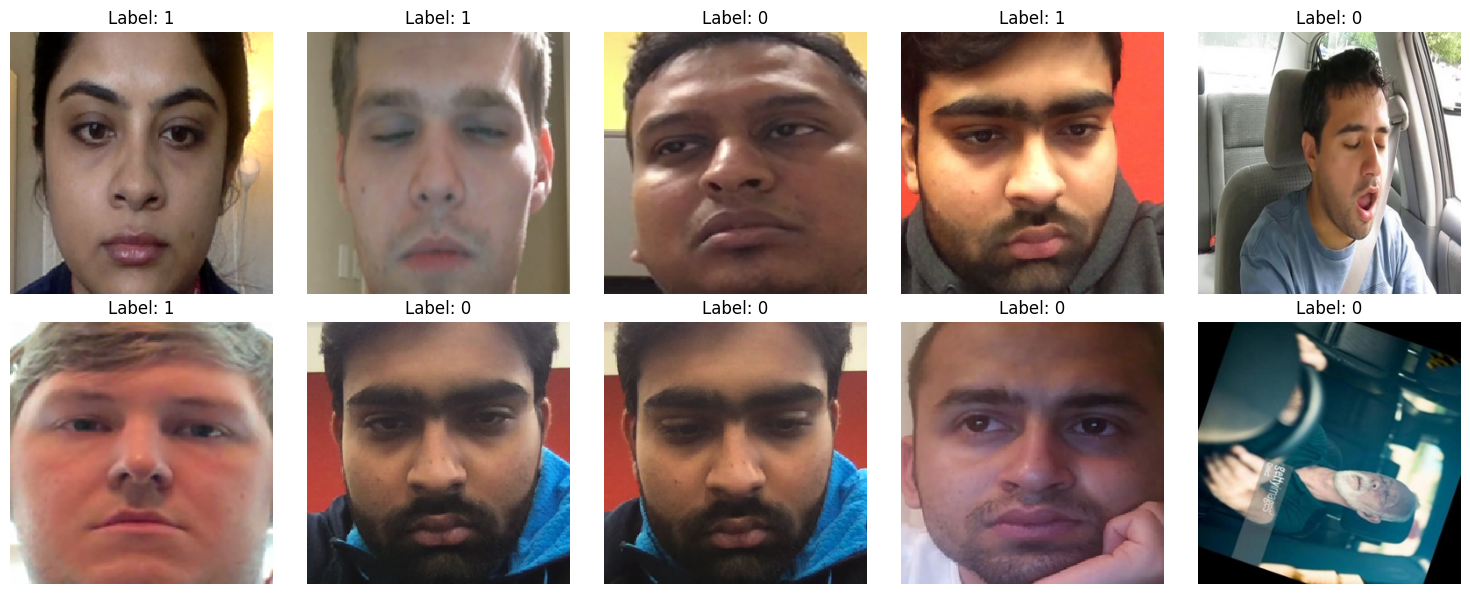

In [15]:
# Add rescale=1./255 to normalize pixel values from [0,255] to [0,1]
viz_datagen = ImageDataGenerator(rescale=1./255)

viz_batches = viz_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,  # (300, 300)
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

def show_random_images(generator, n=10):
    images, labels = next(generator)
    
    n = min(n, len(images))
    
    plt.figure(figsize=(15, 6))
    
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])  # No manual clipping needed
        plt.title(f"Label: {int(labels[i])}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images(viz_batches, 10)

In [16]:
print("\n--- Class Distribution ---")
for name, batches in zip(['Train', 'Validation', 'Test'],
                         [train_batches, val_batches, test_batches]):
    counts = Counter(batches.classes)
    print(f"{name}: {dict(counts)}")


--- Class Distribution ---
Train: {np.int32(0): 26768, np.int32(1): 22056}
Validation: {np.int32(0): 5019, np.int32(1): 4135}
Test: {np.int32(0): 1673, np.int32(1): 1379}


# **Neural Network *(NN)***

Helper Methods

In [17]:
def conv_fn(x, filters, kernel, strides=1, padding='same'):
    """Conv2D + BatchNormalization + ReLU, returns the direct output."""
    x = Conv2D(filters, kernel, strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

Inception Customized Methods

In [18]:
def reduction_A_maker_fn(x):
    branch1 = MaxPooling2D((3, 3), strides=2, padding='valid')(x)

    branch2 = Conv2D(384, 3, strides=2, padding='valid', use_bias=True)(x)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)

    branch3 = conv_fn(x, 256, 1, padding='same')
    branch3 = conv_fn(branch3, 256, 3, padding='same')
    branch3 = Conv2D(384, 3, strides=2, padding='valid', use_bias=True)(branch3)
    branch3 = BatchNormalization()(branch3)
    branch3 = Activation('relu')(branch3)

    return Concatenate()([branch1, branch2, branch3])

def inception_resnet_B_maker_fn(x):
    in_channels = x.shape[-1]
    b1 = conv_fn(x, 192, 1)
    b2 = conv_fn(x, 128, 1)
    b2 = conv_fn(b2, 160, (1, 7))
    b2 = conv_fn(b2, 192, (7, 1))
    mixed = Concatenate()([b1, b2])
    mixed = Conv2D(in_channels, 1, padding='same', use_bias=True)(mixed)
    mixed = BatchNormalization()(mixed)
    return Activation('relu')(Add()([x, mixed]))

def reduction_B_maker_fn(x):
    b1 = MaxPooling2D((3, 3), strides=2, padding='valid')(x)

    b2 = conv_fn(x, 256, 1)
    b2 = Conv2D(384, 3, strides=2, padding='valid', use_bias=True)(b2)
    b2 = BatchNormalization()(b2)
    b2 = Activation('relu')(b2)

    b3 = conv_fn(x, 256, 1)
    b3 = Conv2D(256, 3, strides=2, padding='valid', use_bias=True)(b3)
    b3 = BatchNormalization()(b3)
    b3 = Activation('relu')(b3)

    b4 = conv_fn(x, 256, 1)
    b4 = conv_fn(b4, 256, 3, padding='same')
    b4 = Conv2D(256, 3, strides=2, padding='valid', use_bias=True)(b4)
    b4 = BatchNormalization()(b4)
    b4 = Activation('relu')(b4)

    return Concatenate()([b1, b2, b3, b4])


Build Hybrid Model

In [19]:
def build_model(input_shape=(300, 300, 3)):
    inputs = Input(shape=input_shape)
    backbone = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
    x = backbone.output

    # Add custom blocks
    x = reduction_A_maker_fn(x)
    x = inception_resnet_B_maker_fn(x)

    x = reduction_B_maker_fn(x)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model, backbone

In [20]:
model, backbone = build_model()
backbone.trainable = False

model.summary()

I0000 00:00:1777731385.930678      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 24,802,352 (94.61 MB)

 Trainable params: 14,006,465 (53.43 MB)

 Non-trainable params: 10,795,887 (41.18 MB)

# **Train**

In [21]:
class_counts = Counter(train_batches.classes)
total = sum(class_counts.values())
class_weight = {
    0: total / (2 * class_counts[0]),
    1: total / (2 * class_counts[1])
}
print(f"\nClass weights: {class_weight}")


Class weights: {0: 0.9119844590555888, 1: 1.1068190061661225}


In [22]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.3, patience=4, mode='max', min_lr=1e-6),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1)
]

Phase 1: Training the Head

In [23]:
history1 = model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=8,
    class_weight=class_weight,
    callbacks=callbacks_phase1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8


I0000 00:00:1777731419.588711     705 service.cc:152] XLA service 0x7b0428004390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777731419.588761     705 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777731424.517302     705 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777731450.946982     705 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1526/1526 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.8038 - auc: 0.8824 - loss: 0.4707 - precision: 0.7935 - recall: 0.7686
Epoch 1: val_auc improved from -inf to 0.98703, saving model to best_model_phase1.keras
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 1101s 685ms/step - accuracy: 0.8038 - auc: 0.8824 - loss: 0.4706 - precision: 0.7936 - recall: 0.7687 - val_accuracy: 0.9284 - val_auc: 0.9870 - val_loss: 0.1422 - val_precision: 0.9179 - val_recall: 0.9243 - learning_rate: 3.0000e-04
Epoch 2/8
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9141 - auc: 0.9783 - loss: 0.1804 - precision: 0.9318 - recall: 0.8741
Epoch 2: val_auc improved from 0.98703 to 0.98756, saving model to best_model_phase1.keras
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 982s 643ms/step - accuracy: 0.9141 - auc: 0.9783 - loss: 0.1803 - precision: 0.9318 - recall: 0.8741 - val_accuracy: 0.9348 - val_auc: 0.9876 - val_loss: 0.1327 - val_precision: 0.9692 - val_recall: 0.8837 - learning_rate: 3.0000e-04
Epoch 3/8
1526/1526 

Phase 2: Fine-Tuning

In [24]:
# keras.backend.clear_session()

model = keras.models.load_model('best_model_phase1.keras', compile=False)

for layer in model.layers:
    layer.trainable = False

for layer in model.layers:
    if layer.name.startswith("block6") or layer.name.startswith("top") or layer.name.startswith("dense"):
        layer.trainable = True
        print(f"Layer {layer.name} is trainable")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_auc', patience=8, mode='max', restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', factor=0.3, patience=5, mode='max', min_lr=1e-7),
    ModelCheckpoint('best_model_finetuned.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1)
]

Layer block6a_expand_conv is trainable
Layer block6a_expand_bn is trainable
Layer block6a_expand_activation is trainable
Layer block6a_dwconv_pad is trainable
Layer block6a_dwconv is trainable
Layer block6a_bn is trainable
Layer block6a_activation is trainable
Layer block6a_se_squeeze is trainable
Layer block6a_se_reshape is trainable
Layer block6a_se_reduce is trainable
Layer block6a_se_expand is trainable
Layer block6a_se_excite is trainable
Layer block6a_project_conv is trainable
Layer block6a_project_bn is trainable
Layer block6b_expand_conv is trainable
Layer block6b_expand_bn is trainable
Layer block6b_expand_activation is trainable
Layer block6b_dwconv is trainable
Layer block6b_bn is trainable
Layer block6b_activation is trainable
Layer block6b_se_squeeze is trainable
Layer block6b_se_reshape is trainable
Layer block6b_se_reduce is trainable
Layer block6b_se_expand is trainable
Layer block6b_se_excite is trainable
Layer block6b_project_conv is trainable
Layer block6b_project_bn

In [25]:
history2 = model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=8,
    class_weight=class_weight,
    callbacks=callbacks_phase2
)

Epoch 1/8


2026-05-02 16:30:16.275647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 16:30:16.494399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 337/1526 ━━━━━━━━━━━━━━━━━━━━ 12:26 628ms/step - accuracy: 0.8112 - auc: 0.8948 - loss: 0.4976 - precision: 0.8619 - recall: 0.6991

2026-05-02 16:34:15.495163: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 16:34:15.716314: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1526/1526 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.8722 - auc: 0.9445 - loss: 0.3141 - precision: 0.8962 - recall: 0.8120
Epoch 1: val_auc improved from -inf to 0.99021, saving model to best_model_finetuned.keras
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 1103s 687ms/step - accuracy: 0.8722 - auc: 0.9445 - loss: 0.3140 - precision: 0.8962 - recall: 0.8120 - val_accuracy: 0.9434 - val_auc: 0.9902 - val_loss: 0.1179 - val_precision: 0.9531 - val_recall: 0.9200 - learning_rate: 1.0000e-05
Epoch 2/8
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9447 - auc: 0.9906 - loss: 0.1189 - precision: 0.9604 - recall: 0.9140
Epoch 2: val_auc improved from 0.99021 to 0.99130, saving model to best_model_finetuned.keras
1526/1526 ━━━━━━━━━━━━━━━━━━━━ 990s 649ms/step - accuracy: 0.9447 - auc: 0.9906 - loss: 0.1189 - precision: 0.9604 - recall: 0.9140 - val_accuracy: 0.9484 - val_auc: 0.9913 - val_loss: 0.1117 - val_precision: 0.9510 - val_recall: 0.9340 - learning_rate: 1.0000e-05
Epoch 3/8
1526

In [26]:
model = keras.models.load_model('best_model_finetuned.keras')

# Plot Training Curves

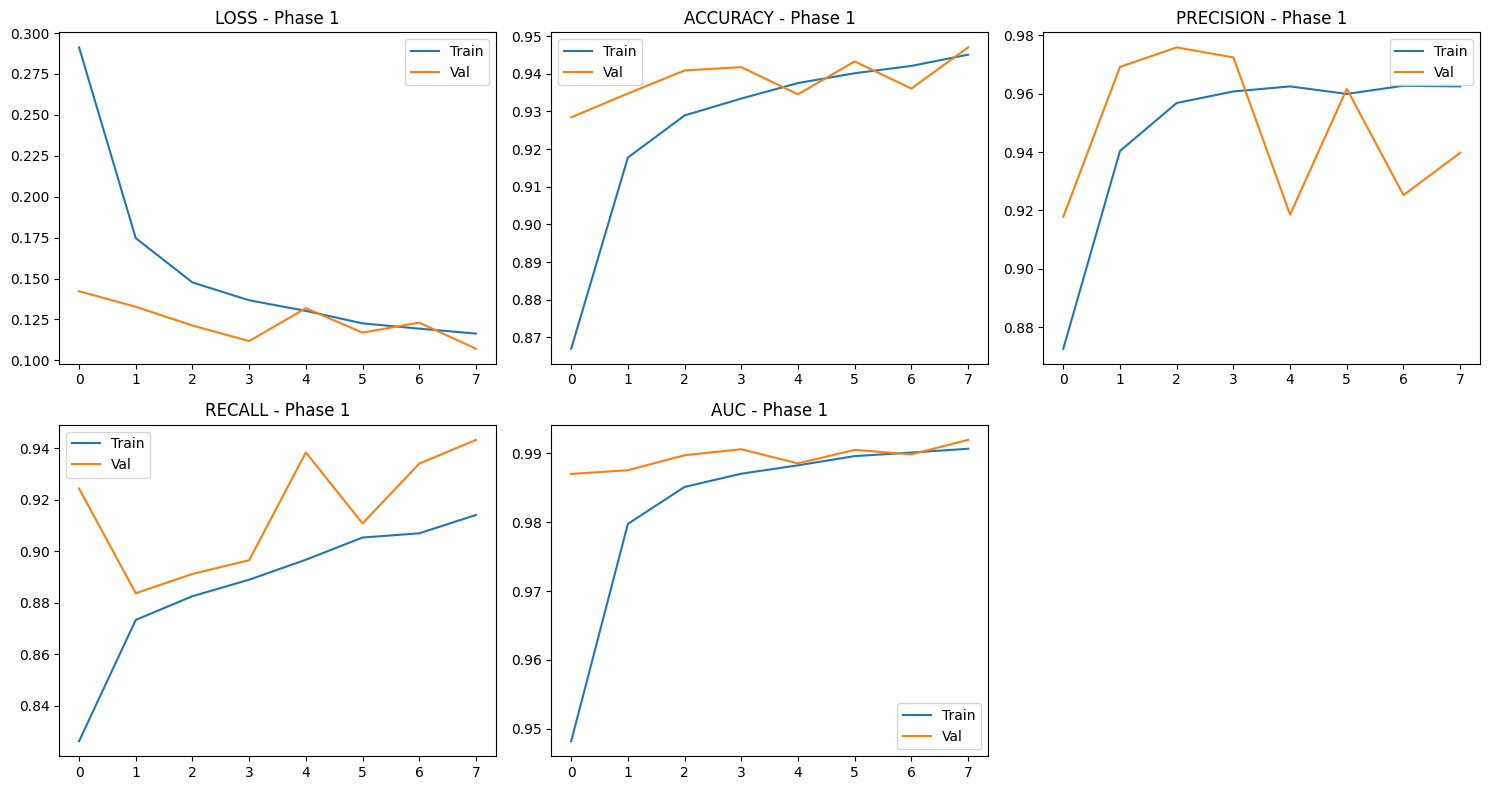

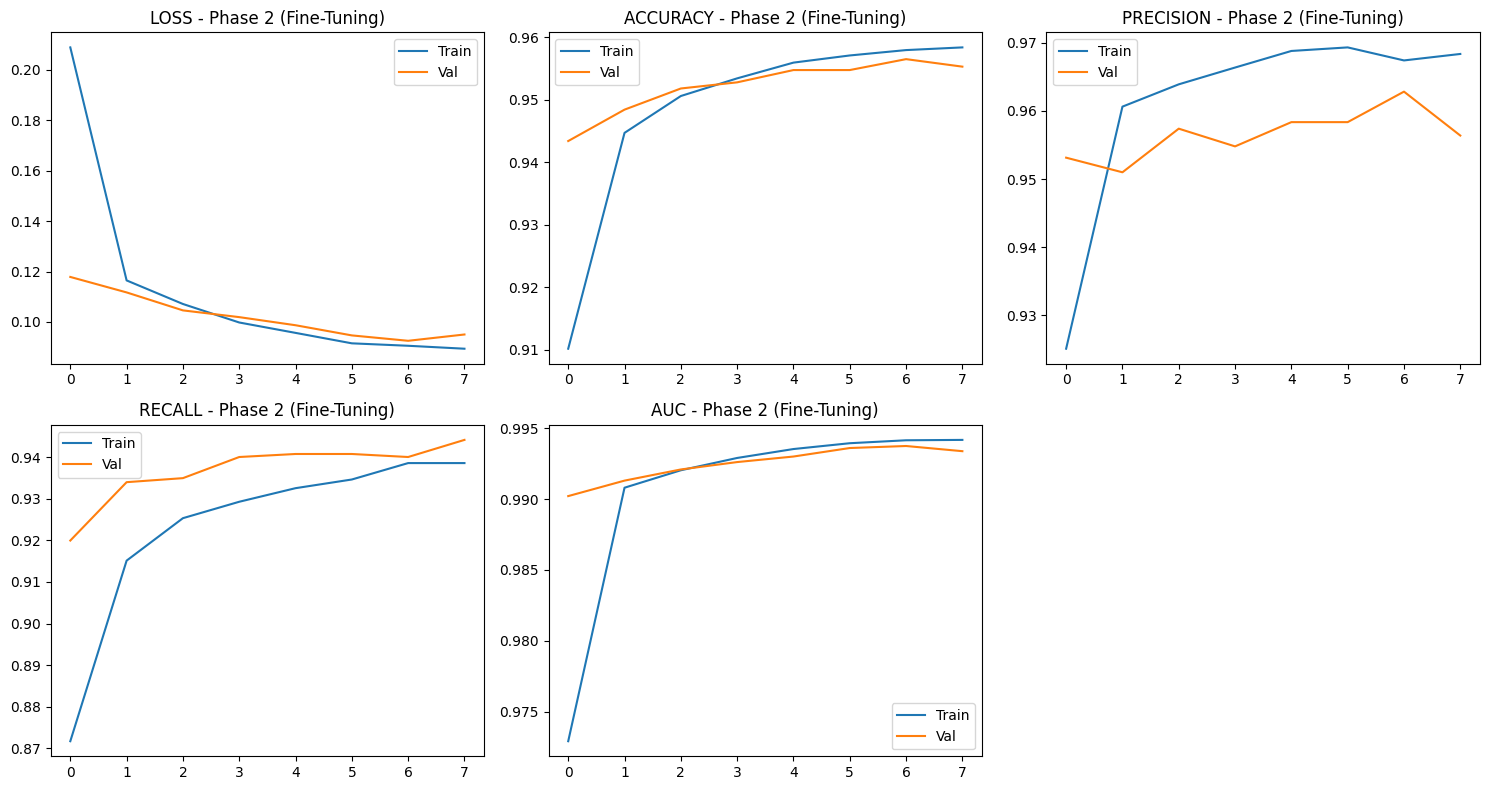

In [27]:
def plot_training(history, title):
    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(history.history[metric], label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Val')
        ax.set_title(f'{metric.upper()} - {title}')
        ax.legend()
    # Hide the sixth (empty) subplot
    axes[-1].axis('off')
    plt.tight_layout()
    plt.show()

plot_training(history1, 'Phase 1')
plot_training(history2, 'Phase 2 (Fine-Tuning)')

# Evaluate

In [28]:
print("\n--- Evaluation on Test Set ---")
test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(test_batches, verbose=0)
print(f"Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, AUC: {test_auc:.4f}")

y_pred_probs = model.predict(test_batches).flatten()
y_true = test_batches.classes



--- Evaluation on Test Set ---


2026-05-02 18:44:52.463092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:44:52.676296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:44:52.916669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 18:44:53.129613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Loss: 0.0932, Acc: 0.9541, Prec: 0.9613, Rec: 0.9362, AUC: 0.9935
96/96 ━━━━━━━━━━━━━━━━━━━━ 34s 241ms/step


# Threshold Tuning

In [32]:
test_datagen = ImageDataGenerator(
    # preprocessing_function=preprocess_input
    rescale = 1./255
)

test_batchesv2 = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='binary', shuffle=False, seed=SEED
)

Found 3052 images belonging to 2 classes.


Class indices: {'Drowsy': 0, 'Non_Drowsy': 1}

Best threshold : 0.63
Best macro F1  : 0.9553


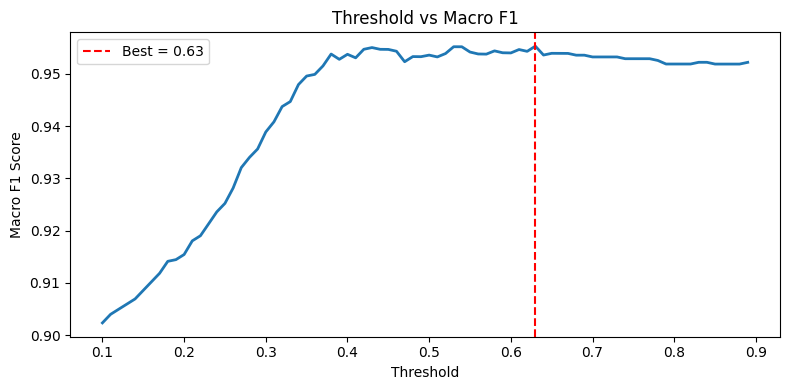


--- Classification Report (Optimized Threshold 0.63) ---
              precision    recall  f1-score   support

  Non Drowsy       0.93      0.99      0.96      1673
      Drowsy       0.99      0.91      0.95      1379

    accuracy                           0.96      3052
   macro avg       0.96      0.95      0.96      3052
weighted avg       0.96      0.96      0.96      3052



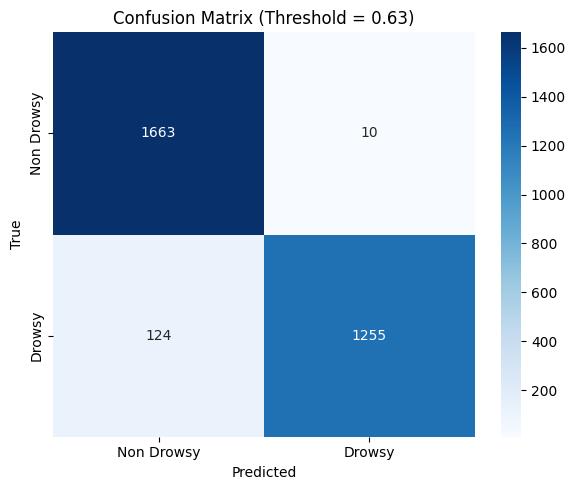

In [35]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Sanity-check class mapping ──────────────────────────────────────────────
print("Class indices:", test_batches.class_indices)
# Expected something like: {'Drowsy': 1, 'Non Drowsy': 0}

# ── 2. Get predicted probabilities (run only if you haven't already) ───────────
# y_pred_probs = model.predict(test_batches).flatten()
# y_true = test_batches.classes

# ── 3. Find best threshold using macro F1 ─────────────────────────────────────
thresholds = np.arange(0.10, 0.90, 0.01)
best_thresh = 0.5
best_f1 = 0.0
f1_scores = []

for thresh in thresholds:
    preds = (y_pred_probs > thresh).astype(int)
    f1 = f1_score(y_true, preds, average='macro')
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest threshold : {best_thresh:.2f}")
print(f"Best macro F1  : {best_f1:.4f}")

# Safety assertion — catches a collapsed threshold before it ruins your results
assert 0.25 < best_thresh < 0.75, (
    f"Threshold {best_thresh:.2f} looks wrong — check your probability outputs!"
)

# ── 4. Plot F1 vs threshold ────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1 Score')
plt.title('Threshold vs Macro F1')
plt.legend()
plt.tight_layout()
plt.show()

# ── 5. Classification report at best threshold ─────────────────────────────────
y_pred_best = (y_pred_probs > best_thresh).astype(int)

print(f"\n--- Classification Report (Optimized Threshold {best_thresh:.2f}) ---")
print(classification_report(y_true, y_pred_best, target_names=['Non Drowsy', 'Drowsy']))

# ── 6. Confusion matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Drowsy', 'Drowsy'],
            yticklabels=['Non Drowsy', 'Drowsy'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (Threshold = {best_thresh:.2f})')
plt.tight_layout()
plt.show()

# Test-Time Augmentation (TTA)

In [36]:
def predict_with_tta(model, directory, target_size, batch_size, n_aug=5):
    """
    Predict using an average of n_aug random augmentations on the test data.
    Note: The directory must contain the same subfolder structure as the training data.
    """
    tta_datagen = ImageDataGenerator(
        # rescale=1./255,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        brightness_range=[0.9, 1.1]
    )
    all_probs = []
    for i in range(n_aug):
        print(f"TTA round {i+1}/{n_aug}")
        gen = tta_datagen.flow_from_directory(
            directory,
            target_size=target_size,
            batch_size=batch_size,
            class_mode=None,      # we don't need labels
            shuffle=False
        )
        probs = model.predict(gen)
        all_probs.append(probs.flatten())
    return np.mean(all_probs, axis=0)


In [38]:
print(f"\n--- Applying Test-Time Augmentation (threshold = {best_thresh:.2f}) ---")
y_pred_tta_probs = predict_with_tta(model, test_dir, img_size, batch_size, n_aug=5)
y_pred_tta = (y_pred_tta_probs > best_thresh).astype(int)  # now uses the correct threshold
print(classification_report(y_true, y_pred_tta, target_names=['Non Drowsy', 'Drowsy']))


--- Applying Test-Time Augmentation (threshold = 0.63) ---
TTA round 1/5
Found 3052 images belonging to 2 classes.
96/96 ━━━━━━━━━━━━━━━━━━━━ 63s 654ms/step
TTA round 2/5
Found 3052 images belonging to 2 classes.
96/96 ━━━━━━━━━━━━━━━━━━━━ 63s 656ms/step
TTA round 3/5
Found 3052 images belonging to 2 classes.
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 645ms/step
TTA round 4/5
Found 3052 images belonging to 2 classes.
96/96 ━━━━━━━━━━━━━━━━━━━━ 63s 654ms/step
TTA round 5/5
Found 3052 images belonging to 2 classes.
96/96 ━━━━━━━━━━━━━━━━━━━━ 64s 667ms/step
              precision    recall  f1-score   support

  Non Drowsy       0.93      0.99      0.96      1673
      Drowsy       0.99      0.91      0.95      1379

    accuracy                           0.95      3052
   macro avg       0.96      0.95      0.95      3052
weighted avg       0.96      0.95      0.95      3052

